# 01 — PaySim data audit

Concise exploratory audit of the PaySim raw dataset.

**Prediction moment:** immediately before transaction authorization.

Column-level modeling decisions live in [`docs/feature_contract.md`](../docs/feature_contract.md). This notebook does **not** engineer features, split data, or train models.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Ensure the src package is importable when the kernel cwd is notebooks/
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fraud_risk.data import EXPECTED_COLUMNS, load_raw_data

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

df = load_raw_data(REPO_ROOT / "data" / "raw")
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print("Expected columns:", list(EXPECTED_COLUMNS))

Loaded 6,362,620 rows × 11 columns
Expected columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


## 1. Dataset overview

Shape, sample rows, dtypes, and missing-value counts.

In [2]:
print("Shape:", df.shape)
display(df.head())
print("\nDtypes:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



Dtypes:


,dtype
step,int64
type,str
amount,float64
nameOrig,str
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,str
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64



Missing values:


,missing
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


## 2. Target distribution (`isFraud`)

,metric,value
0,total_transactions,6.362620e+06
1,fraud_transactions,8.213000e+03
2,legitimate_transactions,6.354407e+06
3,fraud_percentage,1.291000e-01


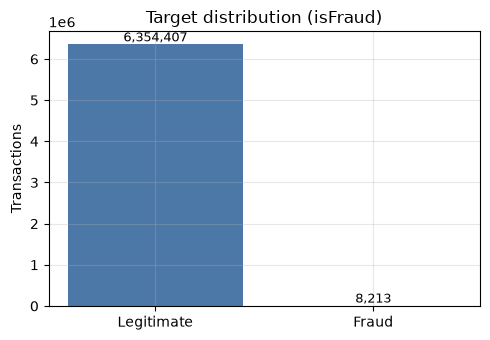

In [3]:
total = len(df)
fraud = int(df["isFraud"].sum())
legit = total - fraud
fraud_pct = 100.0 * fraud / total if total else float("nan")

target_summary = pd.DataFrame(
    {
        "metric": [
            "total_transactions",
            "fraud_transactions",
            "legitimate_transactions",
            "fraud_percentage",
        ],
        "value": [total, fraud, legit, round(fraud_pct, 4)],
    }
)
display(target_summary)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Legitimate", "Fraud"], [legit, fraud], color=["#4C78A8", "#E45756"])
ax.set_ylabel("Transactions")
ax.set_title("Target distribution (isFraud)")
for i, v in enumerate([legit, fraud]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Transaction type analysis

,transactions,fraud_cases,fraud_rate
type,,,
CASH_OUT,2237500,4116,0.001840
PAYMENT,2151495,0,0.000000
CASH_IN,1399284,0,0.000000
TRANSFER,532909,4097,0.007688
DEBIT,41432,0,0.000000


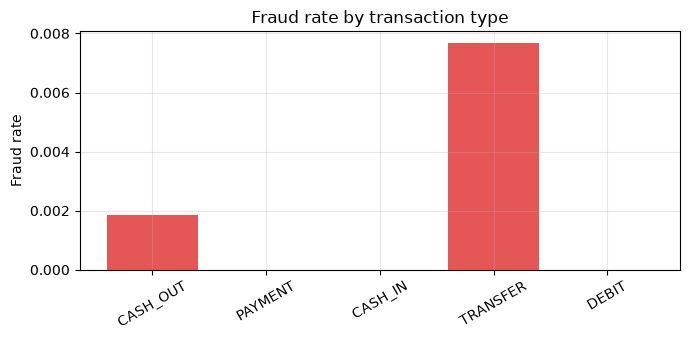

In [4]:
by_type = (
    df.groupby("type", observed=True)
    .agg(transactions=("isFraud", "size"), fraud_cases=("isFraud", "sum"))
    .assign(fraud_rate=lambda x: x["fraud_cases"] / x["transactions"])
    .sort_values("transactions", ascending=False)
)
display(by_type)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(by_type.index.astype(str), by_type["fraud_rate"], color="#E45756")
ax.set_ylabel("Fraud rate")
ax.set_title("Fraud rate by transaction type")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 4. Temporal overview (`step`)

Simple coverage of the simulation clock. **No temporal train/test split yet.**

min step: 1
max step: 743


,transactions,fraud_cases,fraud_rate
step,,,
1,2708,16,0.005908
2,1014,8,0.007890
3,552,4,0.007246
4,565,10,0.017699
5,665,6,0.009023
6,1660,22,0.013253
7,6837,12,0.001755
8,21097,12,0.000569
9,37628,19,0.000505


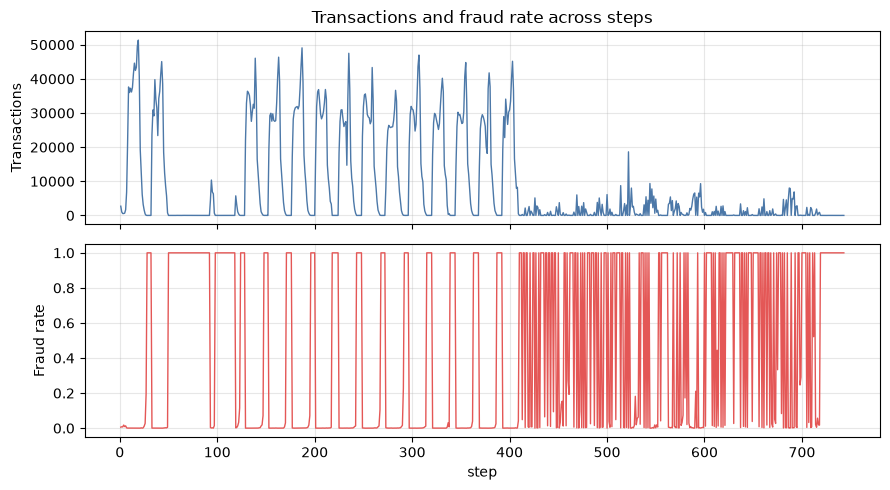

In [5]:
print(f"min step: {df['step'].min()}")
print(f"max step: {df['step'].max()}")

step_stats = (
    df.groupby("step", observed=True)
    .agg(transactions=("isFraud", "size"), fraud_cases=("isFraud", "sum"))
    .assign(fraud_rate=lambda x: x["fraud_cases"] / x["transactions"])
)
display(step_stats.head(10))

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(step_stats.index, step_stats["transactions"], color="#4C78A8", lw=1)
axes[0].set_ylabel("Transactions")
axes[0].set_title("Transactions and fraud rate across steps")
axes[1].plot(step_stats.index, step_stats["fraud_rate"], color="#E45756", lw=1)
axes[1].set_ylabel("Fraud rate")
axes[1].set_xlabel("step")
plt.tight_layout()
plt.show()

## 5. Amount analysis

Robust percentiles for fraud vs non-fraud amounts (preferring percentiles over means alone).

isFraud,non_fraud,fraud
p50,7.468472e+04,4.414234e+05
p75,2.083648e+05,1.517771e+06
p90,3.643734e+05,4.521724e+06
p95,5.156104e+05,8.006429e+06
p99,1.586064e+06,1.000000e+07


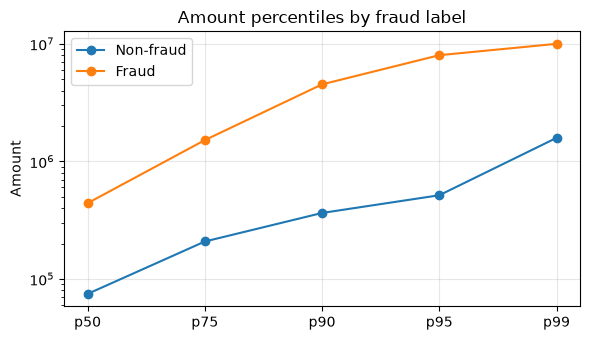

In [6]:
percentiles = [0.50, 0.75, 0.90, 0.95, 0.99]
amount_by_fraud = (
    df.groupby("isFraud")["amount"]
    .quantile(percentiles)
    .unstack(level=0)
    .rename(columns={0: "non_fraud", 1: "fraud"})
)
amount_by_fraud.index = [f"p{int(p * 100)}" for p in amount_by_fraud.index]
display(amount_by_fraud)

fig, ax = plt.subplots(figsize=(6, 3.5))
x = range(len(amount_by_fraud))
ax.plot(list(x), amount_by_fraud["non_fraud"], marker="o", label="Non-fraud")
ax.plot(list(x), amount_by_fraud["fraud"], marker="o", label="Fraud")
ax.set_xticks(list(x))
ax.set_xticklabels(amount_by_fraud.index)
ax.set_ylabel("Amount")
ax.set_title("Amount percentiles by fraud label")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 6. Candidate feature audit

Initial classification only. The authoritative V1 contract is [`docs/feature_contract.md`](../docs/feature_contract.md).

In [7]:
feature_audit = pd.DataFrame(
    [
        {"source_column": "step", "initial_class": "needs review",
         "note": "Temporal key; map carefully to production time"},
        {"source_column": "type", "initial_class": "candidate",
         "note": "Known at authorization"},
        {"source_column": "amount", "initial_class": "candidate",
         "note": "Known at authorization"},
        {"source_column": "nameOrig", "initial_class": "exclude",
         "note": "High-cardinality ID"},
        {"source_column": "oldbalanceOrg", "initial_class": "needs review",
         "note": "Pre-tx originator balance; confirm real availability"},
        {"source_column": "newbalanceOrig", "initial_class": "exclude",
         "note": "Post-transaction balance (leakage)"},
        {"source_column": "nameDest", "initial_class": "exclude",
         "note": "High-cardinality ID"},
        {"source_column": "oldbalanceDest", "initial_class": "needs review",
         "note": "Often unavailable for external destinations"},
        {"source_column": "newbalanceDest", "initial_class": "exclude",
         "note": "Post-transaction balance (leakage)"},
        {"source_column": "isFraud", "initial_class": "target",
         "note": "Label only"},
        {"source_column": "isFlaggedFraud", "initial_class": "exclude",
         "note": "Existing fraud-rule flag"},
    ]
)
display(feature_audit)

,source_column,initial_class,note
0,step,needs review,Temporal key; map carefully to production time
1,type,candidate,Known at authorization
2,amount,candidate,Known at authorization
3,nameOrig,exclude,High-cardinality ID
4,oldbalanceOrg,needs review,Pre-tx originator balance; confirm real availa...
5,newbalanceOrig,exclude,Post-transaction balance (leakage)
6,nameDest,exclude,High-cardinality ID
7,oldbalanceDest,needs review,Often unavailable for external destinations
8,newbalanceDest,exclude,Post-transaction balance (leakage)
9,isFraud,target,Label only


## 7. Modeling Scope Decision

**V1 modeling scope: `TRANSFER` and `CASH_OUT` only.**

In this PaySim extract, fraud labels appear only in those types (`PAYMENT`, `CASH_IN`, and `DEBIT` have zero fraud cases). Restricting V1 avoids an artificially easy problem driven by types with no positive examples. This is a **dataset/simulation property and a project scope choice** — not a claim that those other types can never be fraudulent in real systems.

The cell below reports scoped counts only. It does **not** write a modeling dataset.

In [8]:
V1_TYPES = ["TRANSFER", "CASH_OUT"]
v1_scope = df[df["type"].isin(V1_TYPES)]

scoped_transactions = len(v1_scope)
scoped_fraud = int(v1_scope["isFraud"].sum())
scoped_fraud_pct = 100.0 * scoped_fraud / scoped_transactions if scoped_transactions else float("nan")

scope_summary = pd.DataFrame(
    {
        "metric": [
            "scoped_transactions",
            "scoped_fraud_transactions",
            "scoped_fraud_percentage",
        ],
        "value": [scoped_transactions, scoped_fraud, round(scoped_fraud_pct, 4)],
    }
)
display(scope_summary)

print(
    "V1 will use TRANSFER and CASH_OUT only so training is not dominated by "
    "PaySim types that contain no labeled fraud in this dataset. "
    "No modeling dataset is materialized here — see docs/feature_contract.md."
)


,metric,value
0,scoped_transactions,2.770409e+06
1,scoped_fraud_transactions,8.213000e+03
2,scoped_fraud_percentage,2.965000e-01


V1 will use TRANSFER and CASH_OUT only so training is not dominated by PaySim types that contain no labeled fraud in this dataset. No modeling dataset is materialized here — see docs/feature_contract.md.


---

**Next:** use the feature contract (prediction moment, column decisions, and this type scope) to guide V1 feature selection and temporal validation. Do not treat post-transaction balances or `isFlaggedFraud` as predictors.